In [1]:
import pandas as pd
import numpy as np

df=pd.read_pickle(f"./df.pkl")

In [2]:
df_pdm = df[df["dm"] == 1]

# 무작위 20명 추출 (항상 같은 결과)
df_test = df_pdm.sample(
    n=20,
    random_state=42
).reset_index(drop=True)

print(df_test.shape)

(20, 26)


In [3]:
df_test

,dm,sex,age,edu,income,job,glu,hba1c,hdl,tg,...,wk_mvpa_play,wk_walk,wk_sleep,stress,wk_break,wk_lunch,wk_dinner,wk_veg1,wk_veg2,wk_fruit
0,1,2.0,63.0,3.0,2.0,3.0,109.0,6.0,42.0,303.0,...,0.0,420.0,240.0,1.0,6.0,6.0,6.0,21.0,21.0,14.000
1,1,2.0,60.0,2.0,2.0,6.0,97.0,5.7,33.0,1201.0,...,0.0,0.0,360.0,2.0,0.0,6.0,6.0,14.0,14.0,5.500
2,1,1.0,58.0,1.0,5.0,5.0,107.0,5.5,49.0,209.0,...,10.0,210.0,360.0,2.0,6.0,6.0,6.0,14.0,14.0,0.625
3,1,1.0,50.0,4.0,4.0,2.0,108.0,5.1,41.0,230.0,...,0.0,360.0,360.0,2.0,6.0,6.0,6.0,21.0,21.0,1.000
4,1,1.0,69.0,4.0,3.0,1.0,100.0,5.3,55.0,190.0,...,0.0,420.0,360.0,2.0,6.0,6.0,6.0,21.0,21.0,3.000
5,1,1.0,55.0,3.0,3.0,5.0,98.0,5.9,43.0,110.0,...,0.0,0.0,420.0,1.0,6.0,6.0,6.0,21.0,21.0,3.000
6,1,1.0,41.0,3.0,3.0,6.0,107.0,5.1,61.0,96.0,...,150.0,150.0,480.0,2.0,6.0,6.0,6.0,3.0,3.0,7.000
7,1,2.0,54.0,4.0,3.0,5.0,112.0,5.9,50.0,183.0,...,20.0,175.0,420.0,3.0,6.0,6.0,6.0,14.0,14.0,7.000
8,1,2.0,58.0,4.0,3.0,1.0,118.0,5.8,79.0,103.0,...,0.0,125.0,420.0,2.0,6.0,6.0,6.0,14.0,14.0,7.000
9,1,1.0,63.0,2.0,4.0,3.0,97.0,5.7,49.0,150.0,...,0.0,0.0,480.0,1.0,1.5,6.0,6.0,14.0,14.0,7.000


In [4]:
df_test['wk_smk']

0       0.0
1      49.0
2       0.0
3     119.0
4       0.0
5      49.0
6      70.0
7       0.0
8       0.0
9       0.0
10      0.0
11      0.0
12      0.0
13      0.0
14      0.0
15      0.0
16      0.0
17    140.0
18      0.0
19    189.0
Name: wk_smk, dtype: float64

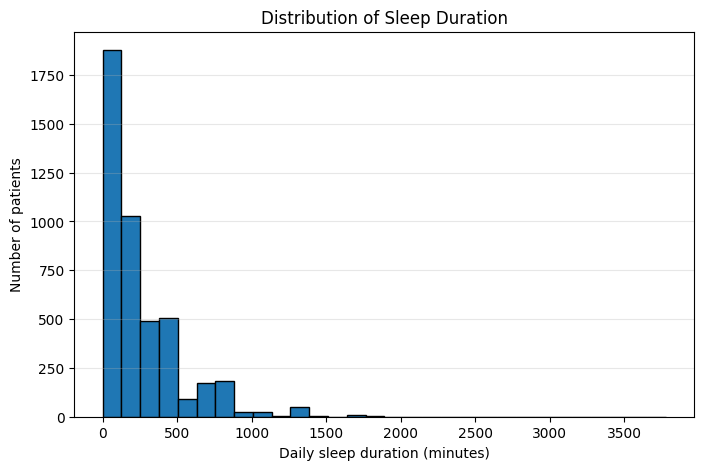

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_pdm["wk_walk"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Daily sleep duration (minutes)")
plt.ylabel("Number of patients")
plt.title("Distribution of Sleep Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

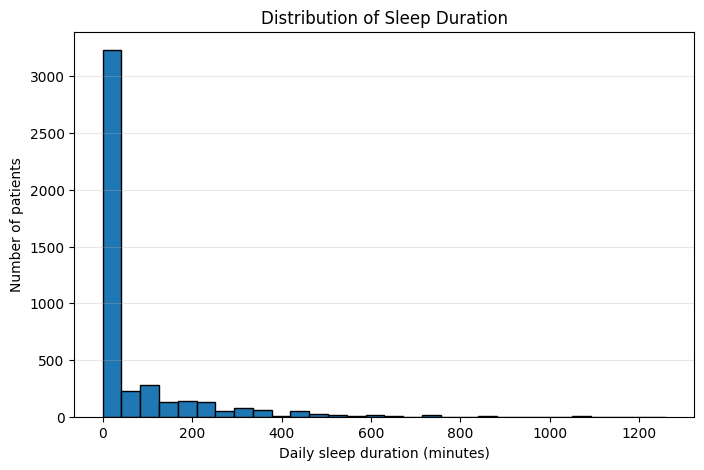

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_pdm["wk_mvpa_play"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Daily sleep duration (minutes)")
plt.ylabel("Number of patients")
plt.title("Distribution of Sleep Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [7]:
from docx import Document
from docx.shared import Pt
from PFPD import PFPD

def get_references_from_context(ctx_item):
    refs = []
    for g in ctx_item.get("guidelines", []):
        meta = g.get("metadata", {})
        ref = meta.get("reference", "")
        if ref and ref not in refs:
            refs.append(ref)
    return "; ".join(refs)


def add_patient_recommendation_to_doc(doc, patient_no, X, current_score, deltas, final_score, recommendation_result, retrieved_context):
    doc.add_heading(f"Patient {patient_no}", level=1)

    doc.add_paragraph(f"Current progression score: {current_score:.3f}")
    doc.add_paragraph(f"Final progression score after lifestyle optimization: {final_score:.3f}")

    doc.add_heading("Recommended lifestyle modifications", level=2)

    for i, (item,ctx) in enumerate(zip(recommendation_result["action_items"],retrieved_context)):
        meta=ctx["item"]
        
        variable=meta["variable"]
        description=meta["description"]
        current_value=meta["current_value"]
        
        reference = get_references_from_context(ctx)
        
        doc.add_paragraph(f"{i+1}. {variable}", style=None)
        doc.add_paragraph(f"Variable: {description}")
        doc.add_paragraph(f"Current value: {current_value}")
        doc.add_paragraph(f"Recommendation: {item.get('recommendation based on delta')}")
        doc.add_paragraph(f"Rationale: {item.get('rationale')}")
        doc.add_paragraph(f"Reference: {reference}")

    doc.add_paragraph(
        "Disclaimer: These recommendations are generated to support lifestyle modification "
        "and do not replace professional medical advice. Please consult your healthcare provider "
        "before making major lifestyle changes."
    )


def generate_word_report_for_40_patients(df_test, output_path="recommendation_report_40_patients.docx"):
    pro = PFPD()
    doc = Document()

    doc.add_heading("Personalized Lifestyle Recommendation Report", level=0)

    for idx, row in df_test.iterrows():
        patient_no = idx + 1

        # row를 기존 X 형태의 dict로 변환
        X = row.to_dict()

        # 필요 없는 컬럼 제거: dm, id 등 모델에 안 들어가는 변수 제거
        for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
            X.pop(col, None)

        current_score = pro.dbs_progression(X)

        deltas, final_score = pro.lifestyle_rec(X)

        recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

        add_patient_recommendation_to_doc(
            doc=doc,
            patient_no=patient_no,
            X=X,
            current_score=current_score,
            deltas=deltas,
            final_score=final_score,
            recommendation_result=recommendation_result,
            retrieved_context=retrieved_context
        )

        # 한 페이지당 2명
        if patient_no % 2 == 0 and patient_no != len(df_test):
            doc.add_page_break()
        else:
            doc.add_paragraph("\n" + "-" * 80 + "\n")

    doc.save(output_path)
    print(f"Saved: {output_path}")

In [8]:
generate_word_report_for_40_patients(
    df_test,
    output_path="recommendation_report_10_patients_epsilon5_lam0.5_lr0.005_step400.docx"
)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] wk_lunch
------------------------------------------------------------
Variable           : Number of days you eat lunch each week
Current value      : 6.0
Recommendation     : Instead of focusing on reducing the number of lunches you eat each week, aim to improve the quality of your lunch meals by including more vegetables such as onions, garlic, celery, and carrots in your cooking and using herbs and spices like basil, mint, cinnamon, or turmeric rather than salt.
Rationale             : Guidelines recommend using herbs and spices to season foods instead of salt and incorporating a variety of vegetables in homemade meals. Planning meals and grocery shopping with a list can help maintain a healthy eating pattern. Emphasizing Mediterranean-style, plant-based, or low-carbohydrate eating patterns with grains, legumes, nuts, moderate fruits and vegetables, and minimal processed foods can prevent diabetes.
Reference          : Medical Nutrition The

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_break
------------------------------------------------------------
Variable           : Number of days you eat breakfast each week
Current value      : 0.0
Recommendation     : Try to start eating breakfast regularly about 6 days per week.
Rationale             : Planning meals for the week and preparing homemade meals in advance can help in establishing regular meal routines. A variety of healthy eating patterns with grains, legumes, nuts, moderate fruits, and vegetables is recommended for diabetes prevention. Including vegetables and using heart-healthy cooking methods helps create balanced meals.
Reference          : Medical Nutrition Therapy - Nutrition Behaviors to encourage, section 5, ADA Standards of Care (2026); Nutrition, section 3, ADA Standards of Care (2026)

[2] stress
------------------------------------------------------------
Variable           : Self-reported stress level, from 1 to 4
Current value      : 2.0
Recommendatio

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

...

Personalized Lifestyle Recommendation

[1] wk_dinner
------------------------------------------------------------
Variable           : Number of days you eat dinner each week
Current value      : 6.0
Recommendation     : Although the model suggests reducing the number of dinners per week, it is important to maintain regular meal patterns. Focus on planning and preparing a variety of healthy dinners each week that include plant-based foods, whole grains, legumes, nuts, moderate fruits and vegetables, and heart-healthy wild-caught fatty fish. Minimize red meat, processed foods, sweets, and sugar-sweetened beverages, and use herbs and spices instead of salt for seasoning.
Rationale             : A variety of eating patterns including Mediterranean-style, plant-based, and low-carbohydrate diets are effective for diabetes prevention. Medical nutrition therapy recommends using herbs and spices to season foods, incorporating vegetables as a base for meals, cooking with healthy vegetable oils,

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_lunch
------------------------------------------------------------
Variable           : Number of days you eat lunch each week
Current value      : 6.0
Recommendation     : Although the model suggests a large reduction in days you eat lunch per week, it is important to maintain a regular eating pattern. Aim to plan varied, balanced meals throughout the week incorporating Mediterranean-style or plant-based eating patterns, including grains, legumes, nuts, moderate fruit, and vegetables. Use herbs and spices instead of salt to season foods, and choose healthy cooking oils such as olive or canola oil. Prepare meals in advance when possible and involve family members to share meal preparation to support consistent, healthful lunches.
Rationale             : The guidelines recommend a variety of eating patterns including Mediterranean-style and plant-based diets that emphasize grains, legumes, nuts, fruits, and vegetables as effective for diabet

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

Personalized Lifestyle Recommendation

[1] wk_dinner
------------------------------------------------------------
Variable           : Number of days you eat dinner each week
Current value      : 6.0
Recommendation     : You currently eat dinner about 6 days per week. Instead of reducing your dinner frequency drastically, focus on improving the quality of your dinners by planning meals ahead using herbs and spices instead of salt, incorporating a variety of vegetables, and choosing healthy oils such as olive or canola oil. Include heart-healthy fish regularly and minimize red meat, sweets, and processed foods.
Rationale             : The guidelines recommend planning meals, using herbs and spices instead of salt, incorporating varied vegetables, and cooking with healthy oils. A Mediterranean-style or plant-based eating pattern with minimal processed foods is effective for diabetes prevention. Regular consumption of heart-healthy fish and limiting processed foods supports metabolic heal

In [9]:
# Patient 10만 다시 생성/출력

from PFPD import PFPD
from llm_writer import print_recommendation

pro = PFPD()

# df_test에서 10번째 환자
row = df_test.iloc[9]
X = row.to_dict()

# 모델에 안 들어가는 컬럼 제거
for col in ["dm", "dm_binary", "id", "ID", "patient_id"]:
    X.pop(col, None)

current_score = pro.dbs_progression(X)
deltas, final_score = pro.lifestyle_rec(X)

# recommendation 생성
recommendation_result, retrieved_context = pro.make_patient_friendly_recommendation(X, deltas)

# mismatch 확인
vars_from_context = [ctx["item"]["variable"] for ctx in retrieved_context]
vars_from_llm = [item["variable"] for item in recommendation_result["action_items"]]

print("context:", vars_from_context)
print("llm    :", vars_from_llm)

assert vars_from_context == vars_from_llm, "Variable mismatch occurred"

print("Current score:", current_score)
print("Final score:", final_score)

print_recommendation(recommendation_result, retrieved_context)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\p

Personalized Lifestyle Recommendation

[1] wk_fruit
------------------------------------------------------------
Variable           : Weekly frequency of fruit consumption
Current value      : 7.0
Recommendation     : Gradually increase your fruit consumption to about 3 times per day, aiming to have fruit on most days of the week.
Rationale             : Especially whole fruit—fresh, frozen, or canned in own juice (or no added sugar) are all acceptable fruit options.
Reference          : Medical Nutrition Therapy, section 5, ADA Standards of Care (2026)

[2] wk_dinner
------------------------------------------------------------
Variable           : Number of days you eat dinner each week
Current value      : 6.0
Recommendation     : Focus on planning and preparing nutritious dinners a few times per week using heart-healthy ingredients such as herbs, spices, nonstarchy vegetables, vegetable oils, and include legumes and fatty fish, while minimizing red meat, sugar-sweetened beverages, s

In [10]:
print(f"current score: {pro.dbs_progression(X)}")
deltas, final_score = pro.lifestyle_rec(X)

print(f"recommend: {deltas}")
print(f"final score: {final_score}")

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\Ap

current score: 50.04879379272461


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-p

recommend: {'wk_alc': 0.0, 'wk_mvpa_play': 0.0, 'wk_walk': 420.0, 'wk_sleep': 0.0, 'wk_break': -1.500000355197244, 'wk_dinner': -3.5868310928344727, 'wk_veg1': 2.369234085083008, 'wk_veg2': 7.0, 'wk_fruit': 14.0}
final score: 45.58111572265625


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.5.2, which is newer than your current Lightning version: v2.5.1.post0


In [11]:
X

{'sex': 1.0,
 'age': 63.0,
 'edu': 2.0,
 'income': 4.0,
 'job': 3.0,
 'glu': 97.0,
 'hba1c': 5.7,
 'hdl': 49.0,
 'tg': 150.0,
 'ldl': 169.0,
 'sbp': 148.5,
 'wc': 98.2,
 'bmi': 26.29146539685447,
 'wk_smk': 0.0,
 'wk_alc': 0.1875,
 'wk_mvpa_play': 0.0,
 'wk_walk': 0.0,
 'wk_sleep': 480.0,
 'stress': 1.0,
 'wk_break': 1.5,
 'wk_lunch': 6.0,
 'wk_dinner': 6.0,
 'wk_veg1': 14.0,
 'wk_veg2': 14.0,
 'wk_fruit': 7.0}